installation and import all required libraries


In [1]:
import pandas as pd
import requests
import json
import hashlib
from datetime import datetime, timedelta

Get data from the LAST 30 DAYS

In [2]:
end_date=datetime.utcnow()

start_date=end_date-timedelta(days=30)

start=start_date.strftime('%Y-%m-%d')

end=end_date.strftime('%Y-%m-%d')

print(start)
print(end)

2026-05-01
2026-05-31


C:\Users\acer\AppData\Local\Temp\ipykernel_30572\1712642835.py:1: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  end_date=datetime.utcnow()


Create API URL

In [3]:
url=f"https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&starttime={start}&endtime={end}&minmagnitude=2.5&orderby=time"

print(url)

https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&starttime=2026-05-01&endtime=2026-05-31&minmagnitude=2.5&orderby=time


Fetch live earthquake data

In [4]:
import requests

try:
    response = requests.get(url, timeout=30)
    response.raise_for_status()

    raw_earthquake_data = response.json()
    print("Data fetched successfully!")

except requests.exceptions.RequestException as e:
    print("Error:", e)

Data fetched successfully!


In [5]:
# response=requests.get(url)

# raw_earthquake_data=response.json()

In [6]:
type(raw_earthquake_data)

dict

Save raw JSON

In [7]:
with open(
    "raw_earthquakes.json",
    "w"
) as file:

    json.dump(
        raw_earthquake_data,
        file,
        indent=4
    )

Create MD5 validation hash

In [8]:
raw_data_hash=hashlib.md5(

json.dumps(
raw_earthquake_data,
sort_keys=True
).encode()

).hexdigest()

print(raw_data_hash)

d015b1fa1d5cba1381cb5406c1119331


Understand incoming data

In [9]:
raw_earthquake_data.keys()

dict_keys(['type', 'metadata', 'features', 'bbox'])

In [10]:
#Check number of events:
len(
raw_earthquake_data['features']
)

1761

In [11]:
#inspect one event:
raw_earthquake_data['features'][1]

{'type': 'Feature',
 'properties': {'mag': 3.05,
  'place': '3 km SSE of Boquerón, Puerto Rico',
  'time': 1780178862330,
  'updated': 1780181085520,
  'tz': None,
  'url': 'https://earthquake.usgs.gov/earthquakes/eventpage/pr71518303',
  'detail': 'https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=pr71518303&format=geojson',
  'felt': None,
  'cdi': None,
  'mmi': None,
  'alert': None,
  'status': 'reviewed',
  'tsunami': 0,
  'sig': 143,
  'net': 'pr',
  'code': '71518303',
  'ids': ',us7000spkk,pr71518303,',
  'sources': ',us,pr,',
  'types': ',origin,phase-data,',
  'nst': 24,
  'dmin': 0.02674,
  'rms': 0.12,
  'gap': 213,
  'magType': 'md',
  'type': 'earthquake',
  'title': 'M 3.1 - 3 km SSE of Boquerón, Puerto Rico'},
 'geometry': {'type': 'Point',
  'coordinates': [-67.1535, 18.0041666666667, 13.06]},
 'id': 'pr71518303'}

Understand required columns

Create container

In [12]:
#Create container
records=[]

Flatten nested JSON

In [13]:
# Coordinates extraction is mandatory:
for event in raw_earthquake_data['features']:

    properties=event['properties']

    geometry=event['geometry']

    coordinates=geometry['coordinates']

    records.append({

    "event_id":event['id'],

    "magnitude":
    properties['mag'],

    "place":
    properties['place'],

    "event_time":
    properties['time'],

    "updated_time":
    properties['updated'],

    "tsunami":
    properties['tsunami'],

    "significance":
    properties['sig'],

    "alert":
    properties['alert'],

    "status":
    properties['status'],

    "event_type":
    properties['type'],

    "longitude":
    coordinates[0],

    "latitude":
    coordinates[1],

    "depth_km":
    coordinates[2]

})

Convert into DataFrame

In [14]:
df=pd.DataFrame(records)

In [15]:
df.head()

,event_id,magnitude,place,event_time,updated_time,tsunami,significance,alert,status,event_type,longitude,latitude,depth_km
0,us7000spkp,5.00,"81 km SE of Lae, Papua New Guinea",1780181151647,1780183425040,0,385,None,reviewed,earthquake,147.454400,-7.296800,68.854
1,pr71518303,3.05,"3 km SSE of Boquerón, Puerto Rico",1780178862330,1780181085520,0,143,None,reviewed,earthquake,-67.153500,18.004167,13.060
2,nc75368511,2.52,"22 km SSW of King City, CA",1780176729490,1780180047346,0,98,None,automatic,earthquake,-121.238167,36.036667,9.930
3,us7000spkc,5.60,"137 km SSE of Oistins, Barbados",1780176445699,1780194895490,0,490,green,reviewed,earthquake,-59.102900,11.908400,35.000
4,us7000spkb,4.90,"24 km NNW of Murghob, Tajikistan",1780175759807,1780176921040,0,369,None,reviewed,earthquake,73.821900,38.356400,131.794


Inspect DataFrame shape

In [16]:
#Before cleaning, Data Engineers inspect data size
print("Rows and Columns:")

df.shape

Rows and Columns:


(1761, 13)

In [17]:
#Check column names
df.columns

Index(['event_id', 'magnitude', 'place', 'event_time', 'updated_time',
       'tsunami', 'significance', 'alert', 'status', 'event_type', 'longitude',
       'latitude', 'depth_km'],
      dtype='object')

Check missing values BEFORE cleaning

In [18]:
#Assignment requires a quality report with missing values before and after cleaning.
#Store BEFORE counts:
missing_before=df.isnull().sum()

print(missing_before)


event_id           0
magnitude          0
place              0
event_time         0
updated_time       0
tsunami            0
significance       0
alert           1697
status             0
event_type         0
longitude          0
latitude           0
depth_km           0
dtype: int64


missing value rules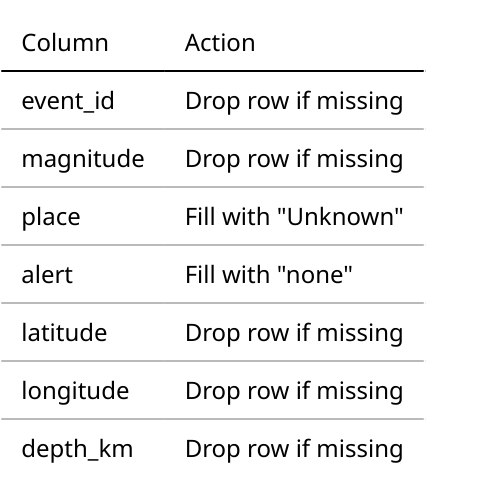

In [19]:
df['place']=df['place'].fillna(
    "Unknown"
)

df['alert']=df['alert'].fillna(
    "none"
)

df=df.dropna(
subset=[

'event_id',

'magnitude',

'latitude',

'longitude',

'depth_km'

]
)

Verify cleaning worked

In [20]:
missing_after=df.isnull().sum()

print(missing_after)

event_id        0
magnitude       0
place           0
event_time      0
updated_time    0
tsunami         0
significance    0
alert           0
status          0
event_type      0
longitude       0
latitude        0
depth_km        0
dtype: int64


Remove duplicates

In [21]:
#Before removing:
duplicates_before=df.shape[0]
#Remove:
df=df.drop_duplicates(
subset=['event_id']
)
#Count:
duplicates_after=df.shape[0]

duplicates_removed=(
duplicates_before-
duplicates_after
)

print(
duplicates_removed
)


0


Data type conversion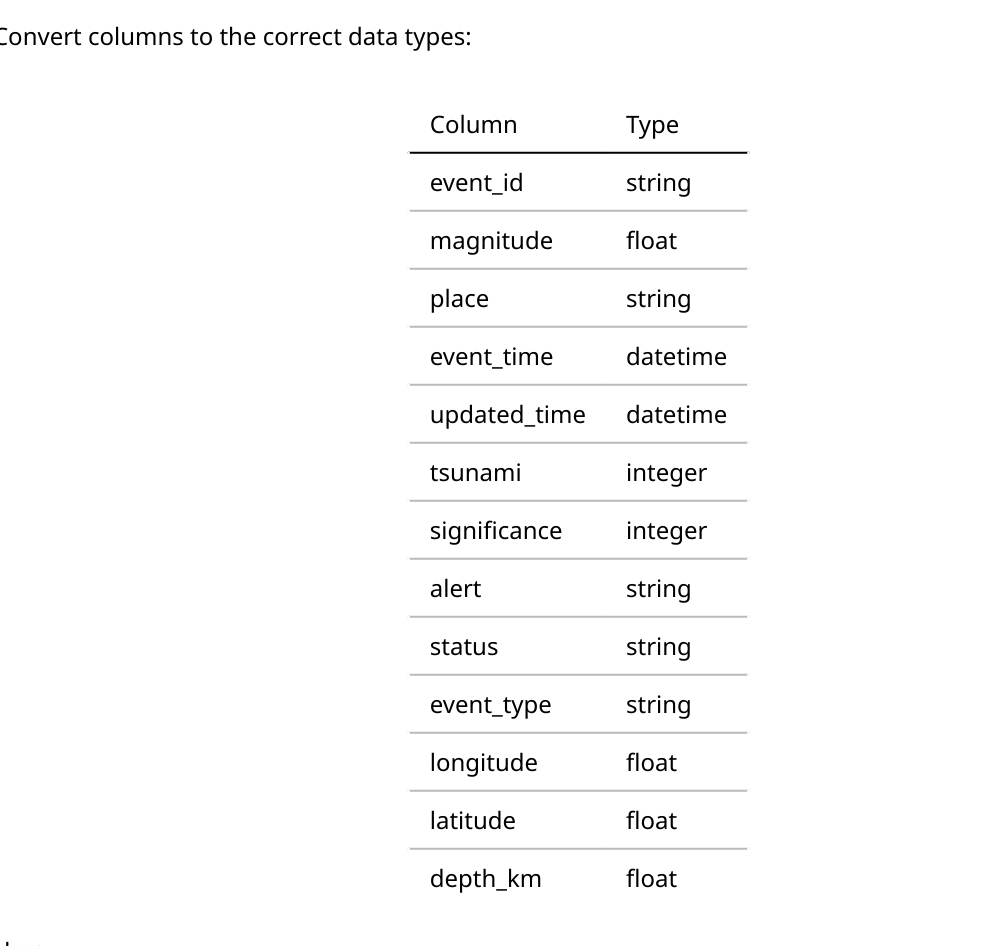

In [22]:
#Before:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   event_id      1761 non-null   object 
 1   magnitude     1761 non-null   float64
 2   place         1761 non-null   object 
 3   event_time    1761 non-null   int64  
 4   updated_time  1761 non-null   int64  
 5   tsunami       1761 non-null   int64  
 6   significance  1761 non-null   int64  
 7   alert         1761 non-null   object 
 8   status        1761 non-null   object 
 9   event_type    1761 non-null   object 
 10  longitude     1761 non-null   float64
 11  latitude      1761 non-null   float64
 12  depth_km      1761 non-null   float64
dtypes: float64(4), int64(4), object(5)
memory usage: 179.0+ KB


In [23]:
#Now convert.
df['event_id']=df[
'event_id'
].astype(str)


df['magnitude']=df[
'magnitude'
].astype(float)


df['place']=df[
'place'
].astype(str)


df['tsunami']=df[
'tsunami'
].fillna(0).astype(int)


df['significance']=df[
'significance'
].fillna(0).astype(int)


df['longitude']=df[
'longitude'
].astype(float)


df['latitude']=df[
'latitude'
].astype(float)


df['depth_km']=df[
'depth_km'
].astype(float)

In [24]:
#after:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   event_id      1761 non-null   object 
 1   magnitude     1761 non-null   float64
 2   place         1761 non-null   object 
 3   event_time    1761 non-null   int64  
 4   updated_time  1761 non-null   int64  
 5   tsunami       1761 non-null   int64  
 6   significance  1761 non-null   int64  
 7   alert         1761 non-null   object 
 8   status        1761 non-null   object 
 9   event_type    1761 non-null   object 
 10  longitude     1761 non-null   float64
 11  latitude      1761 non-null   float64
 12  depth_km      1761 non-null   float64
dtypes: float64(4), int64(4), object(5)
memory usage: 179.0+ KB


In [25]:
#Datetime conversion
df['event_time']=pd.to_datetime(

df['event_time'],

unit='ms',

errors='coerce'
)


df['updated_time']=pd.to_datetime(

df['updated_time'],

unit='ms',

errors='coerce'
)

verify data types

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   event_id      1761 non-null   object        
 1   magnitude     1761 non-null   float64       
 2   place         1761 non-null   object        
 3   event_time    1761 non-null   datetime64[ns]
 4   updated_time  1761 non-null   datetime64[ns]
 5   tsunami       1761 non-null   int64         
 6   significance  1761 non-null   int64         
 7   alert         1761 non-null   object        
 8   status        1761 non-null   object        
 9   event_type    1761 non-null   object        
 10  longitude     1761 non-null   float64       
 11  latitude      1761 non-null   float64       
 12  depth_km      1761 non-null   float64       
dtypes: datetime64[ns](2), float64(4), int64(2), object(5)
memory usage: 179.0+ KB


Text Cleaning
Text standardization

In [27]:
columns=[

'place',

'alert',

'status',

'event_type'

]

for col in columns:

    df[col]=(

        df[col]

        .astype(str)

        .str.strip()

        .str.lower()

    )

In [28]:
#Create place_clean
df['place_clean']=df[
'place'
].str.title()

In [29]:
#check
df[['place',
'place_clean']].head()

,place,place_clean
0,"81 km se of lae, papua new guinea","81 Km Se Of Lae, Papua New Guinea"
1,"3 km sse of boquerón, puerto rico","3 Km Sse Of Boquerón, Puerto Rico"
2,"22 km ssw of king city, ca","22 Km Ssw Of King City, Ca"
3,"137 km sse of oistins, barbados","137 Km Sse Of Oistins, Barbados"
4,"24 km nnw of murghob, tajikistan","24 Km Nnw Of Murghob, Tajikistan"


Create Date Features

In [30]:
df['event_year']=df[
'event_time'
].dt.year


df['event_month']=df[
'event_time'
].dt.month


df['event_day']=df[
'event_time'
].dt.day


df['event_hour']=df[
'event_time'
].dt.hour

In [31]:
#check
df[[

'event_time',

'event_year',

'event_month',

'event_day',

'event_hour'

]].head()

,event_time,event_year,event_month,event_day,event_hour
0,2026-05-30 22:45:51.647,2026,5,30,22
1,2026-05-30 22:07:42.330,2026,5,30,22
2,2026-05-30 21:32:09.490,2026,5,30,21
3,2026-05-30 21:27:25.699,2026,5,30,21
4,2026-05-30 21:15:59.807,2026,5,30,21


Why?

Later we can ask:

Which day had most earthquakes?
Which hour had most activity?

**Feature** **Engineering**

Create Risk Level
HIGH:

magnitude ≥6
OR tsunami=1
OR alert = yellow/orange/red

MEDIUM:

magnitude between 4.5–6
OR significance≥600

Else:

LOW

In [32]:
#fuction for above
def risk_level(row):

    if (

        row['magnitude']>=6

        or row['tsunami']==1

        or row['alert'] in
        ['yellow','orange','red']

    ):

        return 'high'


    elif (

        4.5<=row['magnitude']<6

        or row['significance']>=600

    ):

        return 'medium'


    else:

        return 'low'

In [33]:
#applying on risk_level
df['risk_level']=df.apply(
risk_level,
axis=1
)

In [34]:
#checking
df[['magnitude',

'tsunami',

'alert',

'risk_level'

]].head()

,magnitude,tsunami,alert,risk_level
0,5.00,0,none,medium
1,3.05,0,none,low
2,2.52,0,none,low
3,5.60,0,green,medium
4,4.90,0,none,medium


Create Depth Category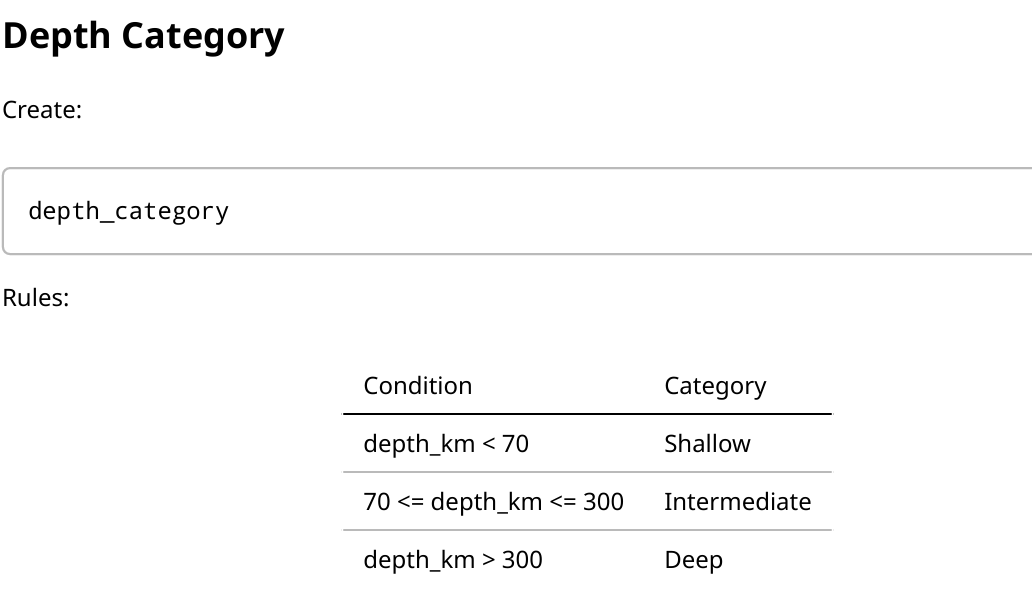

In [35]:
#function for the above
def depth_category(depth):

    if depth<70:

        return 'Shallow'


    elif depth<=300:

        return 'Intermediate'


    else:

        return 'Deep'

In [36]:
#applying
df['depth_category']=df[
'depth_km'
].apply(
depth_category
)

In [37]:
# checking
df[[

'depth_km',

'depth_category'

]].head()

,depth_km,depth_category
0,68.854,Shallow
1,13.060,Shallow
2,9.930,Shallow
3,35.000,Shallow
4,131.794,Intermediate


Region Extraction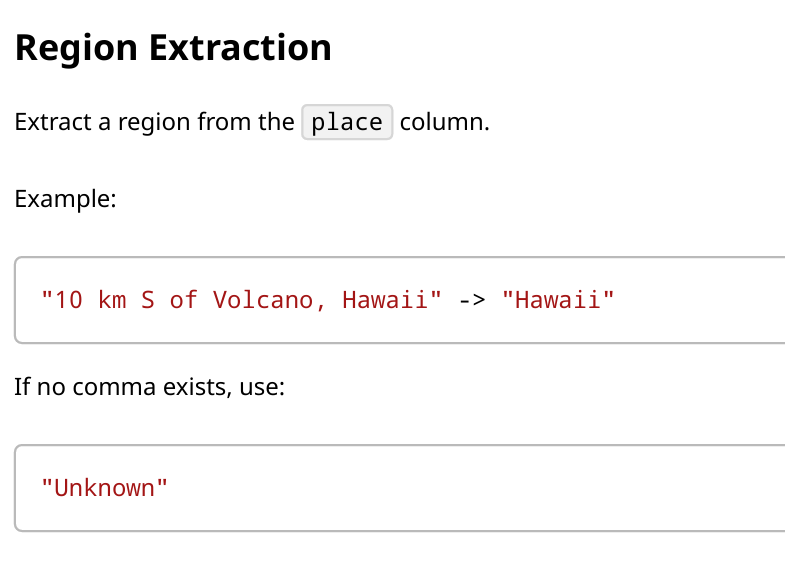

In [38]:
def extract_region(place):

    if ',' in place:

        return place.split(
            ','
        )[-1].strip()

    else:

        return 'Unknown'

In [39]:
#applying
df['region']=df[
'place_clean'
].apply(
extract_region
)


In [40]:
#checking
df[[

'place_clean',

'region'

]].head()


,place_clean,region
0,"81 Km Se Of Lae, Papua New Guinea",Papua New Guinea
1,"3 Km Sse Of Boquerón, Puerto Rico",Puerto Rico
2,"22 Km Ssw Of King City, Ca",Ca
3,"137 Km Sse Of Oistins, Barbados",Barbados
4,"24 Km Nnw Of Murghob, Tajikistan",Tajikistan


Quick verification


In [41]:
df.columns

Index(['event_id', 'magnitude', 'place', 'event_time', 'updated_time',
       'tsunami', 'significance', 'alert', 'status', 'event_type', 'longitude',
       'latitude', 'depth_km', 'place_clean', 'event_year', 'event_month',
       'event_day', 'event_hour', 'risk_level', 'depth_category', 'region'],
      dtype='object')

Output Files

In [42]:
#Save final cleaned CSV
df.to_csv(

'earthquakes_clean.csv',

index=False

)


In [43]:
#Save Parquet file
df.to_parquet(

'earthquakes_clean.parquet',

index=False

)

In [44]:
#Save Raw API JSON
with open(
    "raw_earthquakes.json",
    "w"
) as file:

    json.dump(
        raw_earthquake_data,
        file,
        indent=4
    )

In [45]:
# Raw API JSON
with open(
    "raw_earthquakes.json",
    "w"
) as file:

    json.dump(
        raw_earthquake_data,
        file,
        indent=4
    )


# Clean CSV
df.to_csv(
    "earthquakes_clean.csv",
    index=False
)


# Clean Parquet
df.to_parquet(
    "earthquakes_clean.parquet",
    index=False
)

Create risk counts

In [46]:
high_risk_count=(

df['risk_level']=='high'

).sum()


medium_risk_count=(

df['risk_level']=='medium'

).sum()


low_risk_count=(

df['risk_level']=='low'

).sum()

In [47]:
# cheking
print(high_risk_count)

print(medium_risk_count)

print(low_risk_count)

11
405
1345


Top 5 regions


In [48]:
top_regions=(

df['region']

.value_counts()

.head(5)

.to_dict()

)

In [49]:
top_regions

{'Alaska': 549, 'Unknown': 127, 'Ca': 125, 'Puerto Rico': 74, 'Indonesia': 72}

Data Quality **Report** **bold text**
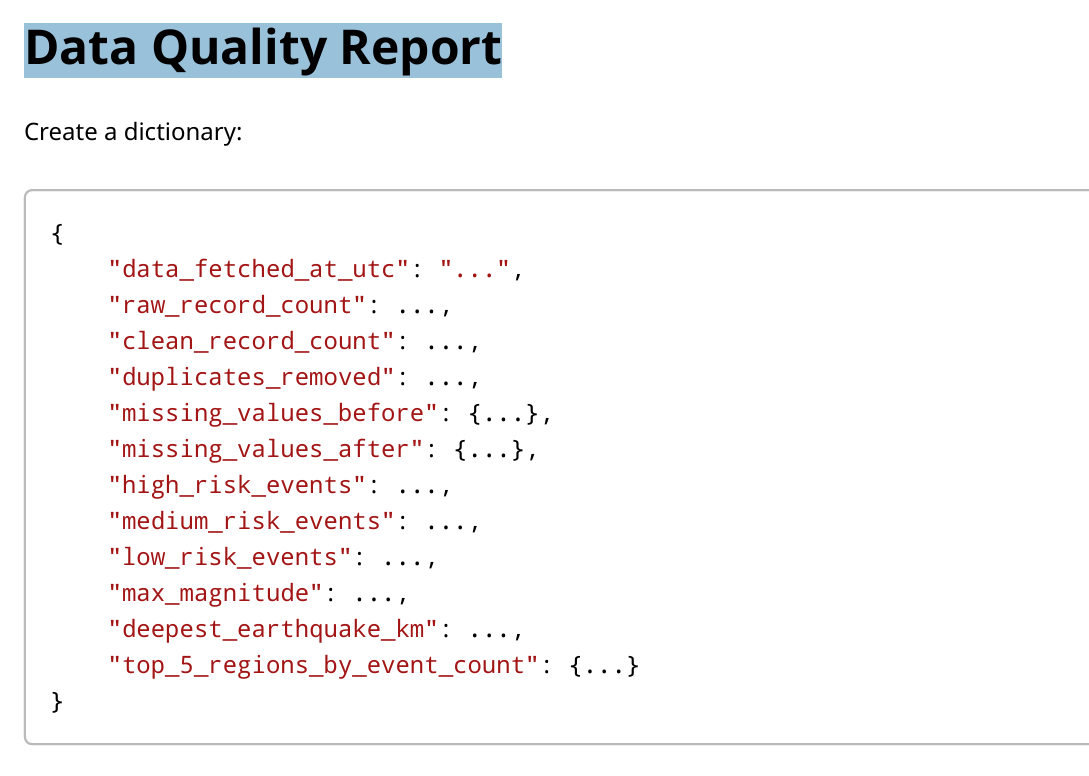

In [50]:
quality_report={

"data_fetched_at_utc":

str(datetime.utcnow()),


"raw_record_count":

len(
raw_earthquake_data[
'features'
]
),


"clean_record_count":

len(df),


"duplicates_removed":

duplicates_removed,


"missing_values_before":

missing_before.to_dict(),


"missing_values_after":

missing_after.to_dict(),


"high_risk_events":

high_risk_count,


"medium_risk_events":

medium_risk_count,


"low_risk_events":

low_risk_count,


"max_magnitude":

df['magnitude'].max(),


"deepest_earthquake_km":

df['depth_km'].max(),


"top_5_regions_by_event_count":

top_regions

}

C:\Users\acer\AppData\Local\Temp\ipykernel_30572\2270761928.py:5: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  str(datetime.utcnow()),


In [51]:
quality_report

{'data_fetched_at_utc': '2026-05-31 06:16:04.291008',
 'raw_record_count': 1761,
 'clean_record_count': 1761,
 'duplicates_removed': 0,
 'missing_values_before': {'event_id': 0,
  'magnitude': 0,
  'place': 0,
  'event_time': 0,
  'updated_time': 0,
  'tsunami': 0,
  'significance': 0,
  'alert': 1697,
  'status': 0,
  'event_type': 0,
  'longitude': 0,
  'latitude': 0,
  'depth_km': 0},
 'missing_values_after': {'event_id': 0,
  'magnitude': 0,
  'place': 0,
  'event_time': 0,
  'updated_time': 0,
  'tsunami': 0,
  'significance': 0,
  'alert': 0,
  'status': 0,
  'event_type': 0,
  'longitude': 0,
  'latitude': 0,
  'depth_km': 0},
 'high_risk_events': np.int64(11),
 'medium_risk_events': np.int64(405),
 'low_risk_events': np.int64(1345),
 'max_magnitude': np.float64(6.9),
 'deepest_earthquake_km': np.float64(639.858),
 'top_5_regions_by_event_count': {'Alaska': 549,
  'Unknown': 127,
  'Ca': 125,
  'Puerto Rico': 74,
  'Indonesia': 72}}

Save report as JSON

In [52]:
import numpy as np

# Convert numpy.int64 values in quality_report to standard Python int
for key, value in quality_report.items():
    if isinstance(value, np.int64):
        quality_report[key] = int(value)

with open(
'quality_report.json',
'w'
) as file:
    json.dump(
    quality_report,
    file,
    indent=4
)

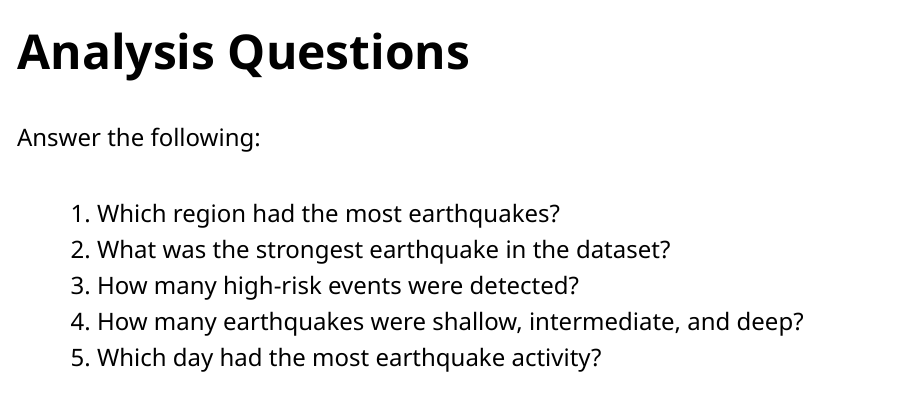

In [53]:
#Which region had most earthquakes?
most_region=(

df['region']

.value_counts()

.idxmax()

)

print(

"Region with most earthquakes:",

most_region

)

Region with most earthquakes: Alaska


In [54]:
#Strongest earthquake:
strongest=df.loc[

df['magnitude']

.idxmax()

]

print(

strongest[
'magnitude'
]

)

print(

strongest[
'place_clean'
]

)

6.9
29 Km Ene Of Calama, Chile


In [55]:
#High-risk events:
print(

"High Risk Events:",

high_risk_count

)

High Risk Events: 11


In [56]:
#Depth categories:
df[
'depth_category'
].value_counts()

depth_category
Shallow         1392
Intermediate     300
Deep              69
Name: count, dtype: int64

In [57]:
#Most active earthquake day:
busy_day=(

df['event_day']

.value_counts()

.idxmax()

)

print(

"Most active day:",

busy_day

)

Most active day: 10


Final file check

In [58]:
!ls

'ls' is not recognized as an internal or external command,
operable program or batch file.


Save Final Data Quality Report

In [59]:
with open(
    "final_data_quality_report.json",
    "w"
) as file:

    json.dump(
        quality_report,
        file,
        indent=4
    )